<a href="https://colab.research.google.com/github/SheikhAli4221/Real_Time_Traffic_Congestion_MLOps_Pipeline/blob/main/EDA_Traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

# 1. Secret URL loading
NEON_URL = userdata.get('DATABASE_URL')

# Safety check: SQLAlchemy requires 'postgresql://' instead of 'postgres://'
if NEON_URL.startswith("postgres://"):
    NEON_URL = NEON_URL.replace("postgres://", "postgresql://")

# 2. SQLAlchemy Engine creation (The Professional Way)
engine = create_engine(NEON_URL)

try:
    # 3. Data from Database to Pandas through Engine
    query = "SELECT * FROM traffic_weather_data;"
    df = pd.read_sql_query(query, engine)

    print("✅ Data successfully pulled to Google Colab without any warnings!")

    # 4. Data Head Visualization
    display(df.head())

    # Bonus Check: How many rows have been collected so far?
    print(f"\n📊 Total Records so far: {df.shape[0]} rows, {df.shape[1]} columns")

except Exception as e:
    print(f"❌ Error: {e}")

✅ Data successfully pulled to Google Colab without any warnings!


,id,location,temperature_c,weather_condition,current_speed_kmh,free_flow_speed_kmh,timestamp,humidity,latitude,longitude,visibility,wind_speed,weather_main,feels_like,current_travel_time,free_flow_travel_time,confidence,road_closure
0,1,Times_Square_NY,17.83,broken clouds,6,10,2026-05-09 17:25:29,65,40.7588,-73.9851,10000,2.68,Clouds,17.37,239,143,1.0,False
1,2,Wall_Street_NY,18.07,light rain,21,21,2026-05-09 17:25:30,63,40.7060,-74.0088,10000,2.68,Rain,17.58,408,408,1.0,False
2,3,Brooklyn_Bridge_NY,17.73,broken clouds,40,46,2026-05-09 17:25:30,67,40.7061,-73.9969,10000,2.68,Clouds,17.31,212,185,1.0,False
3,4,Broadway_Manhattan,17.89,broken clouds,6,10,2026-05-09 17:25:30,64,40.7590,-73.9845,10000,2.68,Clouds,17.41,239,143,1.0,False
4,5,Central_Park_West,17.95,broken clouds,15,15,2026-05-09 17:25:30,64,40.7812,-73.9740,10000,2.68,Clouds,17.47,152,152,1.0,False



📊 Total Records so far: 3600 rows, 18 columns


# **FEATURE ENGINEERING**

In [17]:
import pandas as pd
import numpy as np

# Brutal Honesty: Ensure your data is loaded as 'df' in the cell above this one!

print("🚀 Starting Phase 3: Automated Feature Engineering...")

# ==========================================
# 1. TEMPORAL FEATURES (Extracting Time Magic)
# ==========================================
# Convert string timestamp to proper Python datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract exact hour (0-23) and day of the week (0=Monday, 6=Sunday)
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Flag: Is it the Weekend? (1 if Saturday/Sunday, else 0)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Flag: Is it Rush Hour? (1 if 8-10 AM or 5-8 PM, else 0)
# This will be a massive game-changer for the ML model
rush_hours = [8, 9, 10, 17, 18, 19, 20]
df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if x in rush_hours else 0)

# ==========================================
# 2. TARGET VARIABLE (What we want to predict)
# ==========================================
# Traffic Jam Severity = Normal Speed - Current Speed
df['speed_drop_kmh'] = df['free_flow_speed_kmh'] - df['current_speed_kmh']

# ==========================================
# 3. THE PURGE (Dropping Leaks & Noise)
# ==========================================
# We drop 'feels_like' to avoid confusing the model (it's a twin of temperature_c)
# We drop 'id' because it's useless for machine learning
# We DO NOT drop current_speed_kmh yet because your Bar Charts in the next cell might need it,
# but for the Heatmap, we will isolate only the numeric ML features.

columns_to_drop = ['id', 'feels_like']
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

print("✅ Feature Engineering Complete!")
print(f"📊 New Shape of Data: {df.shape[0]} rows, {df.shape[1]} columns")
print("🔥 Smart Features Added: 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'speed_drop_kmh'")

🚀 Starting Phase 3: Automated Feature Engineering...
✅ Feature Engineering Complete!
📊 New Shape of Data: 3600 rows, 22 columns
🔥 Smart Features Added: 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'speed_drop_kmh'


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install seaborn

# 1. CORELATION HEATMAP

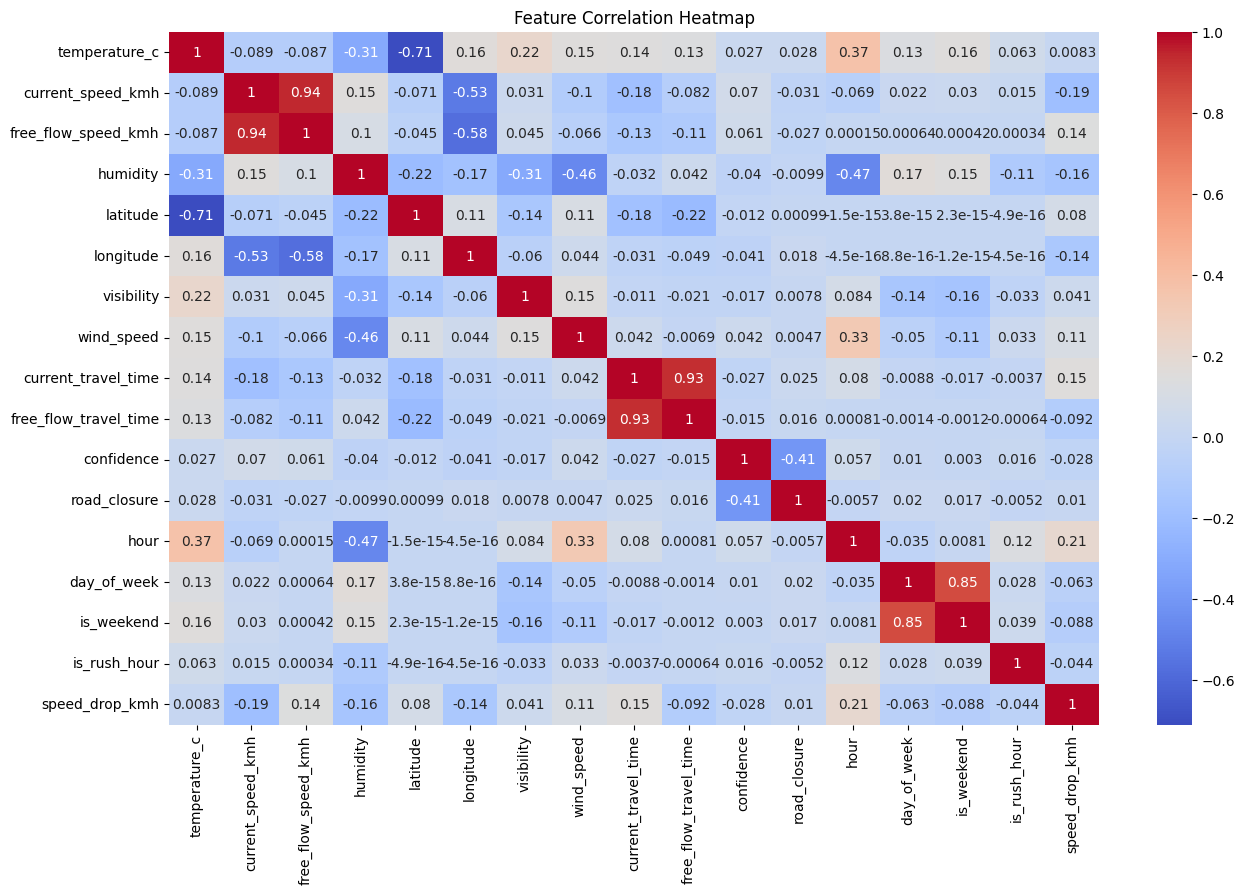

In [20]:
plt.figure(figsize=(15,9))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

# **2. Hourly Traffic Trend**

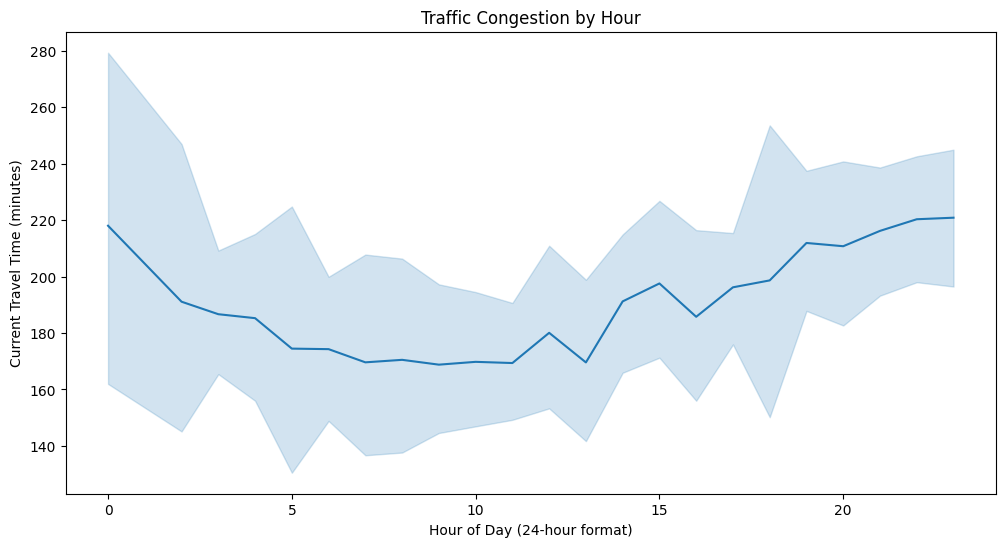

In [19]:
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

plt.figure(figsize=(12,6))

sns.lineplot(
    x='hour',
    y='current_travel_time',
    data=df
)

plt.title("Traffic Congestion by Hour")
plt.xlabel("Hour of Day (24-hour format)")
plt.ylabel("Current Travel Time (minutes)")  # ✅ UNIT FIX

plt.show()

# **3. Congestion by Location**

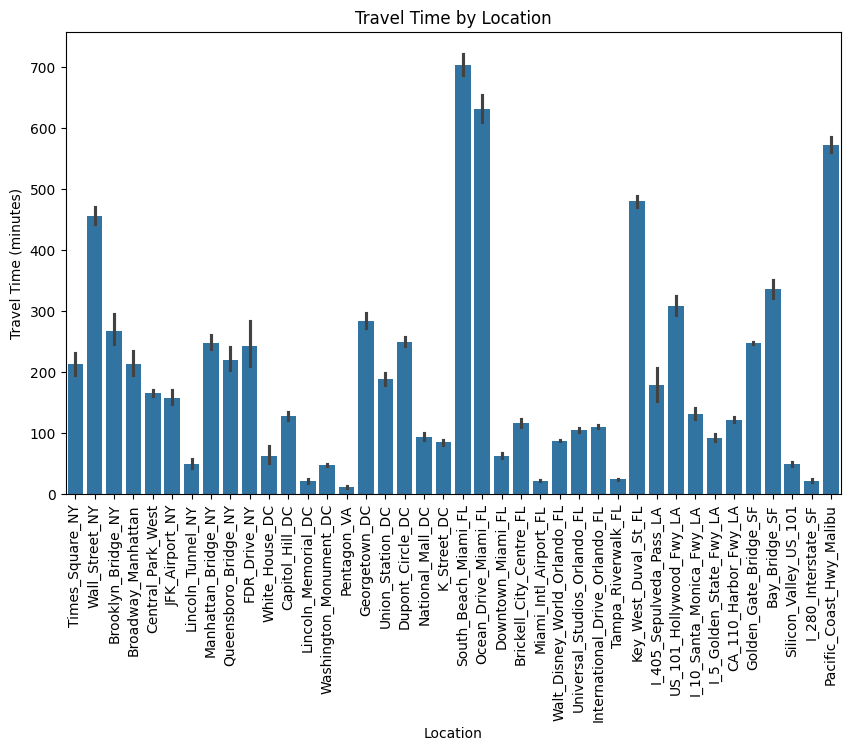

In [7]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='location',
    y='current_travel_time',
    data=df
)

plt.xticks(rotation=90)

plt.title("Travel Time by Location")
plt.xlabel("Location")
plt.ylabel("Travel Time (minutes)")  # ✅ UNIT FIX

plt.show()

# **4. Weather Impact on Speed**

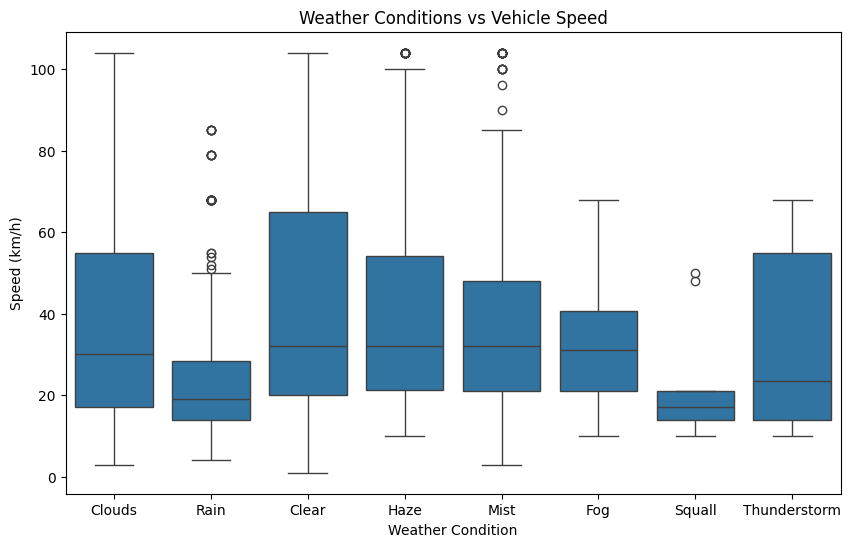

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='weather_main',
    y='current_speed_kmh',
    data=df
)

plt.title("Weather Conditions vs Vehicle Speed")
plt.xlabel("Weather Condition")
plt.ylabel("Speed (km/h)")  # ✅ UNIT FIX

plt.show()

# **5. Speed Distribution**

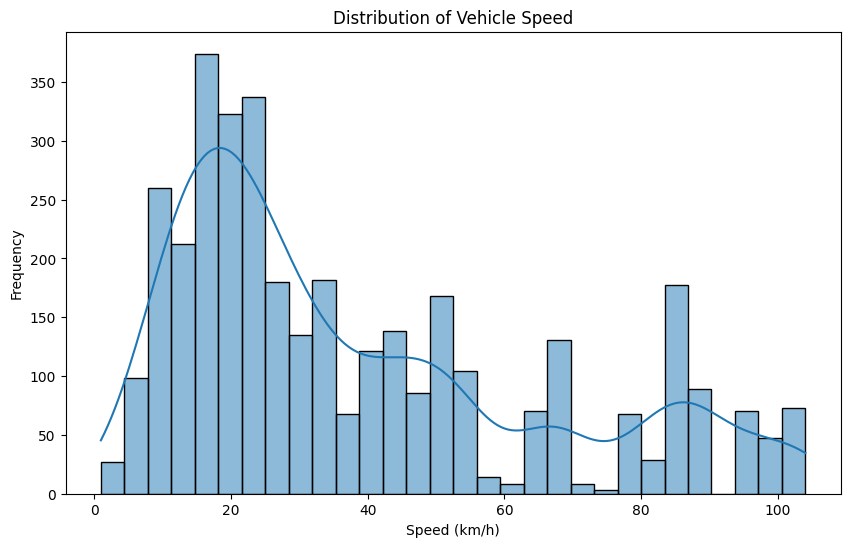

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['current_speed_kmh'],
    bins=30,
    kde=True
)

plt.title("Distribution of Vehicle Speed")
plt.xlabel("Speed (km/h)")  # ✅ UNIT FIX
plt.ylabel("Frequency")

plt.show()

# **6. Speed vs Travel Time**

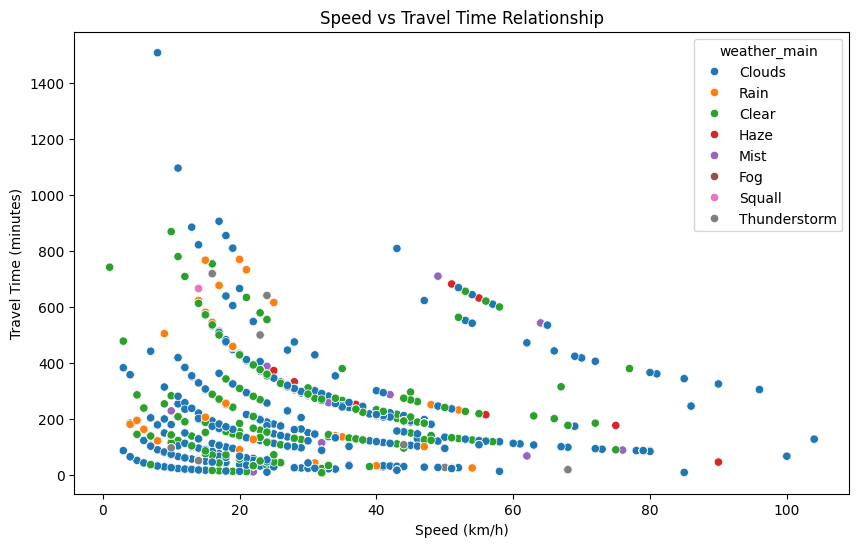

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='current_speed_kmh',
    y='current_travel_time',
    hue='weather_main',
    data=df
)

plt.title("Speed vs Travel Time Relationship")
plt.xlabel("Speed (km/h)")
plt.ylabel("Travel Time (minutes)")  # ✅ UNIT FIX

plt.show()

# **7. Road Closure Impact**

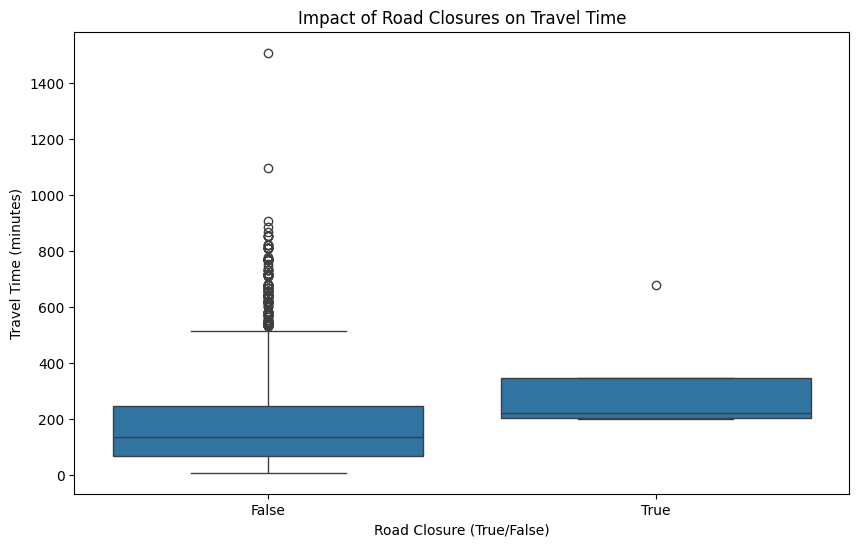

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='road_closure',
    y='current_travel_time',
    data=df
)

plt.title("Impact of Road Closures on Travel Time")
plt.xlabel("Road Closure (True/False)")
plt.ylabel("Travel Time (minutes)")

plt.show()

# **8. Visibility vs Speed**

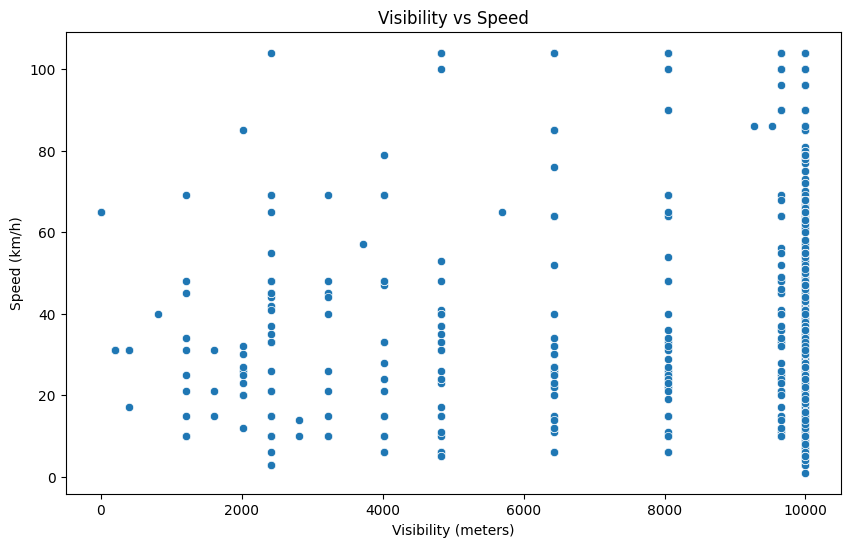

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='visibility',
    y='current_speed_kmh',
    data=df
)

plt.title("Visibility vs Speed")
plt.xlabel("Visibility (meters)")  # IMPORTANT REAL UNIT
plt.ylabel("Speed (km/h)")

plt.show()

# **9. Average Speed by Location**

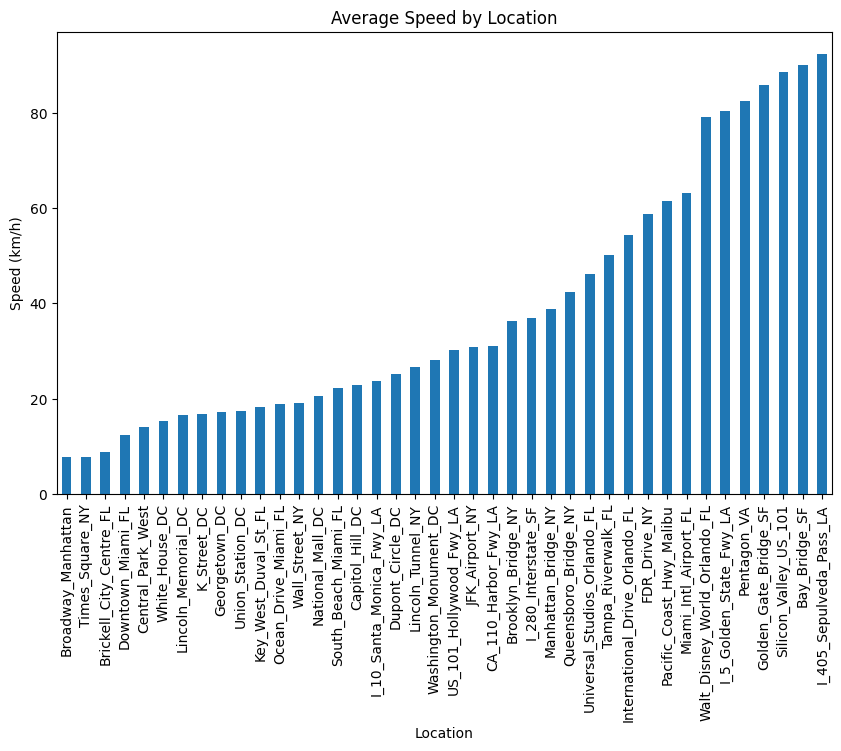

In [14]:
plt.figure(figsize=(10,6))

df.groupby('location')['current_speed_kmh'] \
  .mean() \
  .sort_values() \
  .plot(kind='bar')

plt.title("Average Speed by Location")
plt.xlabel("Location")
plt.ylabel("Speed (km/h)")  # UNIT FIX

plt.show()

## **10. Traffic Severity**

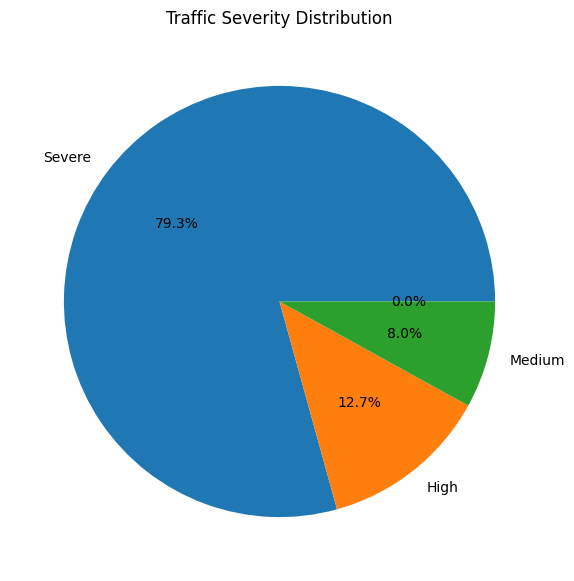

In [15]:
df['traffic_level'] = pd.cut(
    df['current_travel_time'],
    bins=[0,5,10,20,100],
    labels=['Low','Medium','High','Severe']
)

df['traffic_level'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Traffic Severity Distribution")
plt.ylabel("")

plt.show()

# 11. **Pair Plot**

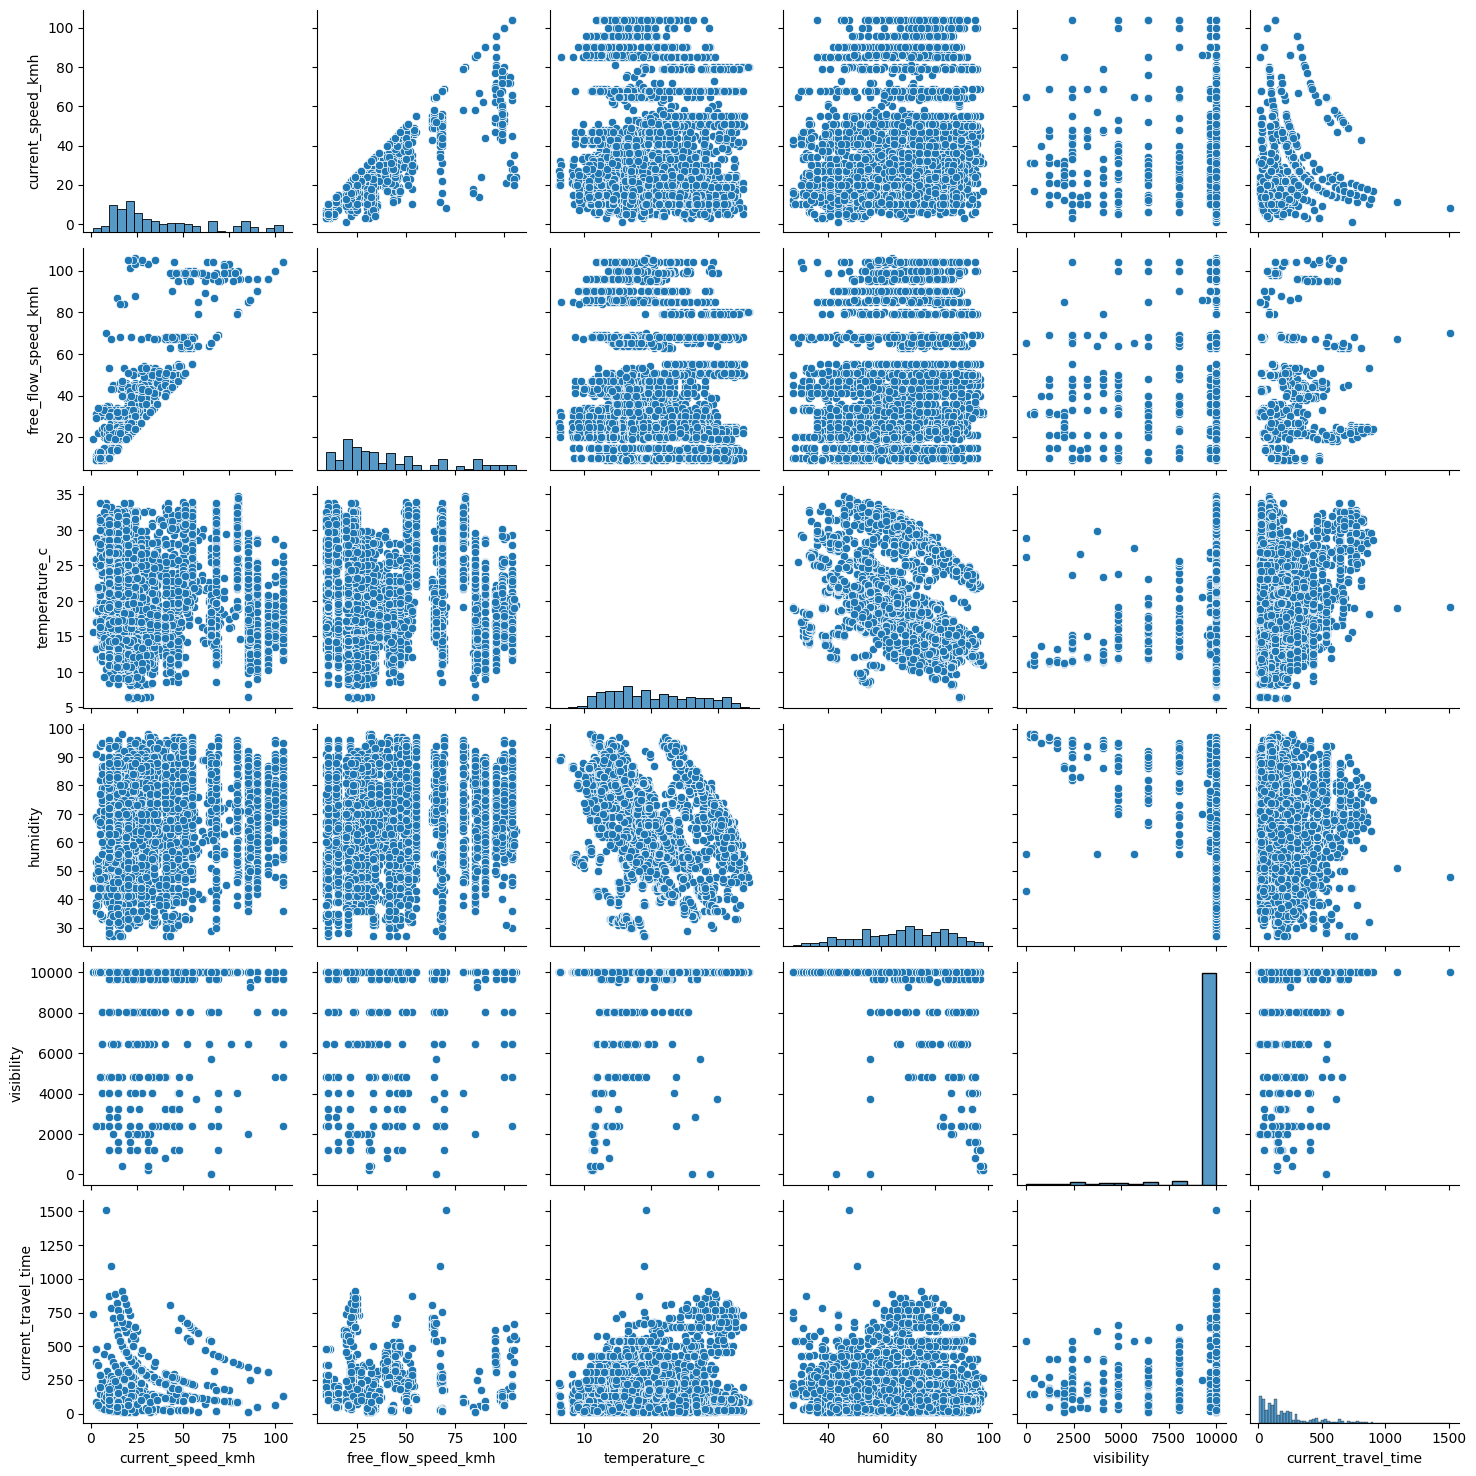

In [16]:
sns.pairplot(df[
    [
        'current_speed_kmh',
        'free_flow_speed_kmh',
        'temperature_c',
        'humidity',
        'visibility',
        'current_travel_time'
    ]
])

plt.show()